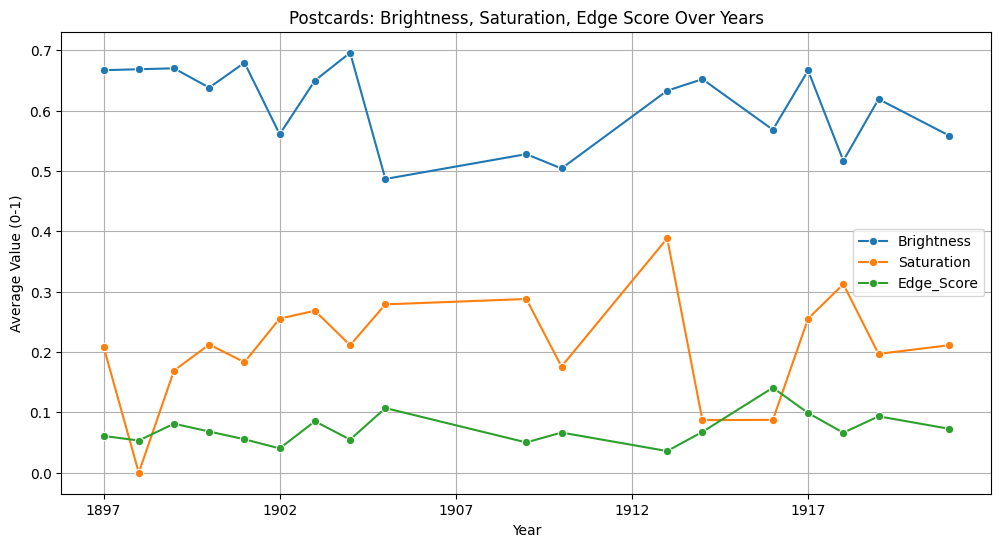

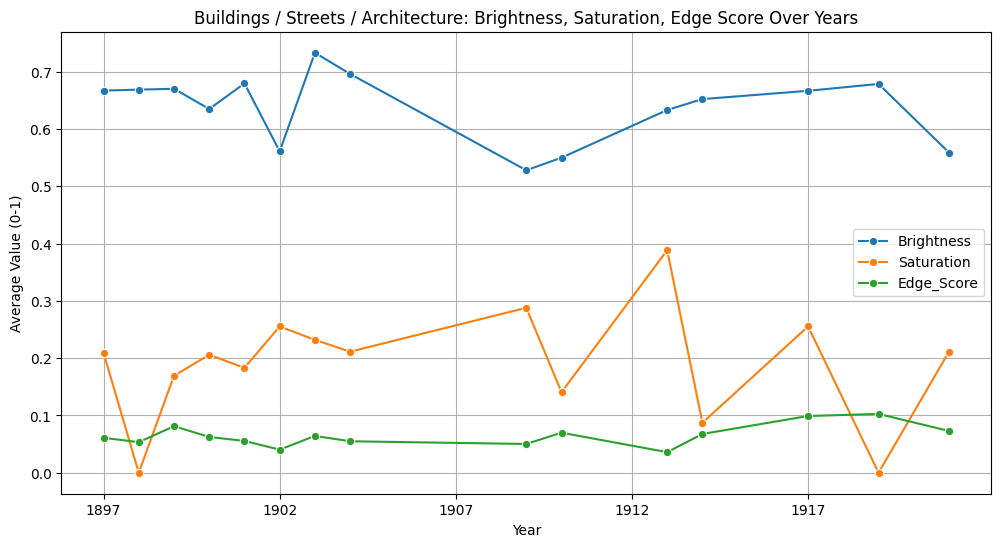

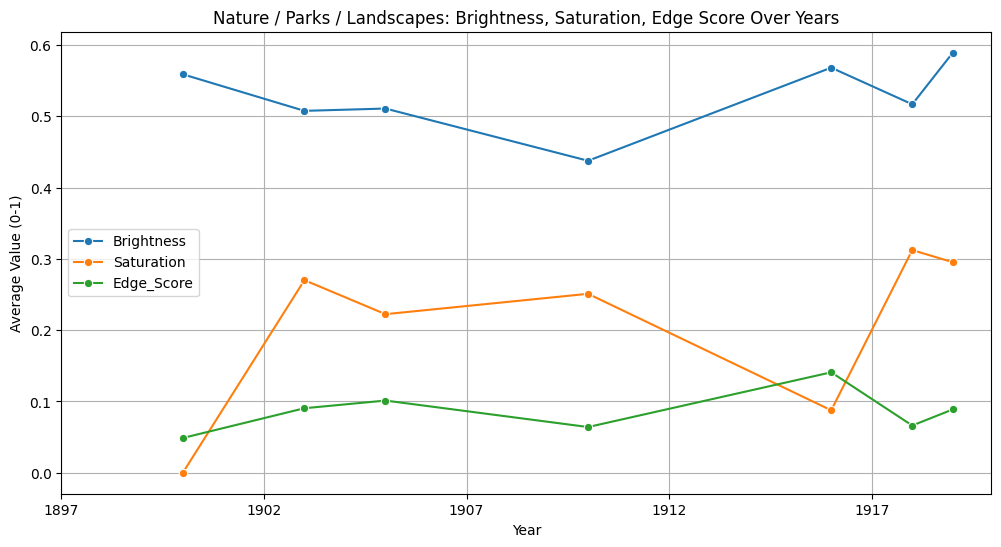

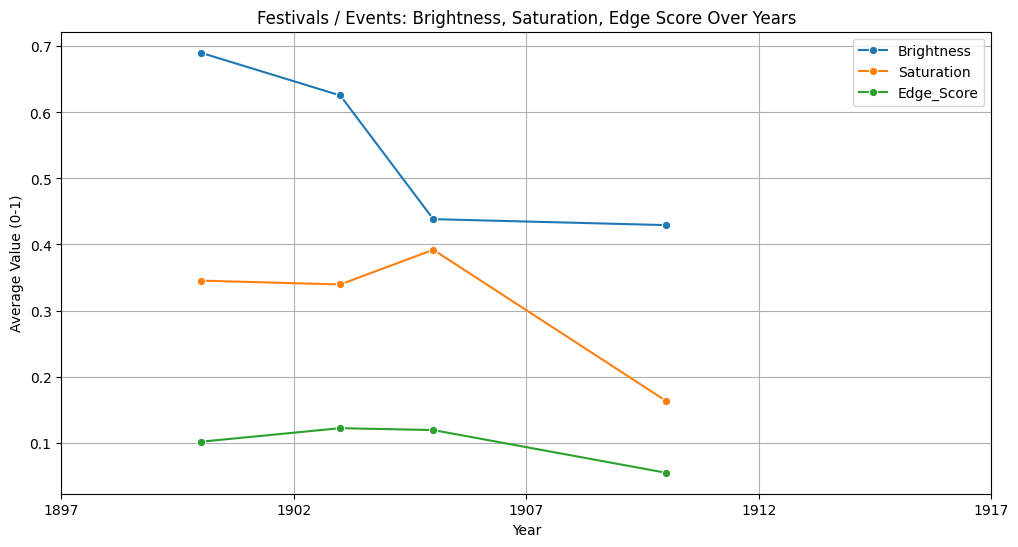

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Step 1: Load CSV ---
df = pd.read_csv("BH.csv")  # Replace with your file path

# --- Step 2: Define metrics ---
metrics = ["Brightness", "Saturation", "Edge_Score"]

# --- Step 3: Get full year range ---
min_year = df["Year"].min()
max_year = df["Year"].max()
full_years = pd.DataFrame({"Year": np.arange(min_year, max_year + 1)})

# --- Step 4: Group by Year and merge with full range ---
yearly_stats = df.groupby("Year")[metrics].mean().reset_index()
yearly_stats = full_years.merge(yearly_stats, on="Year", how="left")  # Fill missing years with NaN

# --- Step 5: Overall line plot ---
plt.figure(figsize=(12,6))
for metric in metrics:
    sns.lineplot(data=yearly_stats, x="Year", y=metric, marker="o", label=metric)
plt.title("Postcards: Brightness, Saturation, Edge Score Over Years")
plt.xlabel("Year")
plt.ylabel("Average Value (0-1)")
plt.xticks(np.arange(min_year, max_year + 1, 5))  # optional: show every 5 years on x-axis
plt.legend()
plt.grid(True)
plt.show()

# --- Step 6: Separate plots by Category ---
categories = df["Category"].unique()

for category in categories:
    cat_df = df[df["Category"] == category].groupby("Year")[metrics].mean().reset_index()
    cat_df = full_years.merge(cat_df, on="Year", how="left")
    
    plt.figure(figsize=(12,6))
    for metric in metrics:
        sns.lineplot(data=cat_df, x="Year", y=metric, marker="o", label=metric)
    
    plt.title(f"{category}: Brightness, Saturation, Edge Score Over Years")
    plt.xlabel("Year")
    plt.ylabel("Average Value (0-1)")
    plt.xticks(np.arange(min_year, max_year + 1, 5))
    plt.legend()
    plt.grid(True)
    plt.show()


C:\Users\srini\AppData\Local\Temp\ipykernel_4484\1431428613.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_colors = df.groupby("Period")[colors].mean()


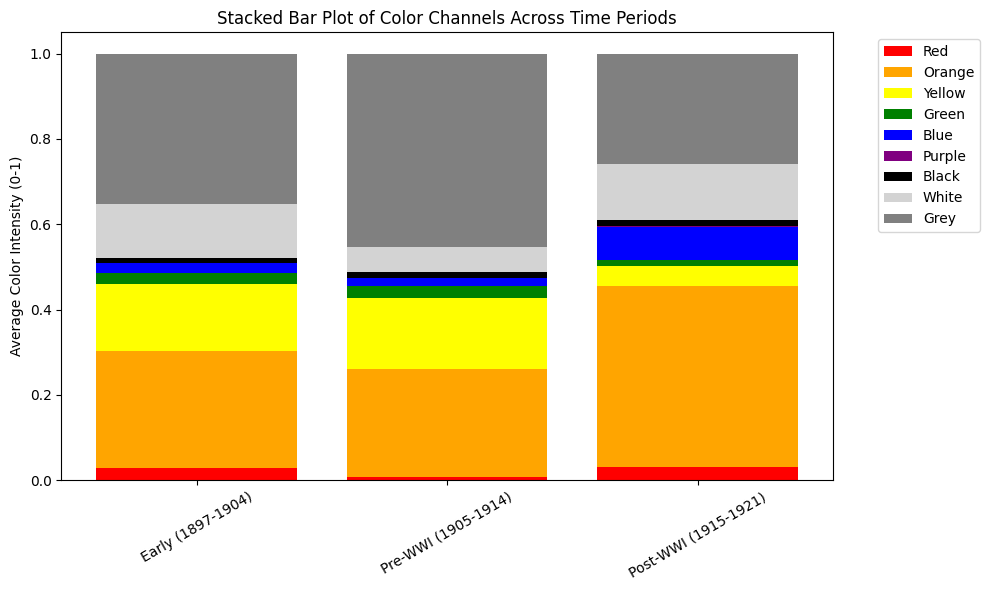

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load CSV ---
df = pd.read_csv("BH.csv")  # Replace with your CSV file path

# --- Step 2: Define color channels and plotting colors ---
colors = ["Red","Orange","Yellow","Green","Blue","Purple","Black","White","Grey"]
plot_colors = ["red","orange","yellow","green","blue","purple","black","lightgrey","grey"]  # for stacked bars

# --- Step 3: Define periods ---
def assign_period(year):
    if 1897 <= year <= 1904:
        return "Early (1897-1904)"
    elif 1905 <= year <= 1914:
        return "Pre-WWI (1905-1914)"
    elif 1915 <= year <= 1921:
        return "Post-WWI (1915-1921)"
    else:
        return "Other"

df["Period"] = df["Year"].apply(assign_period)

# --- Step 4: Define period order ---
period_order = ["Early (1897-1904)", "Pre-WWI (1905-1914)", "Post-WWI (1915-1921)"]
df["Period"] = pd.Categorical(df["Period"], categories=period_order, ordered=True)

# --- Step 5: Group by Period and calculate mean color intensity ---
period_colors = df.groupby("Period")[colors].mean()

# --- Step 6: Plot stacked bar chart ---
fig, ax = plt.subplots(figsize=(10,6))

bottom = pd.Series([0]*len(period_colors), index=period_colors.index)  # starting point for stacking

for color, plot_color in zip(colors, plot_colors):
    ax.bar(period_colors.index, period_colors[color], bottom=bottom, color=plot_color, label=color)
    bottom += period_colors[color]  # update bottom for next stack

ax.set_ylabel("Average Color Intensity (0-1)")
ax.set_title("Stacked Bar Plot of Color Channels Across Time Periods")
plt.xticks(rotation=30)
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


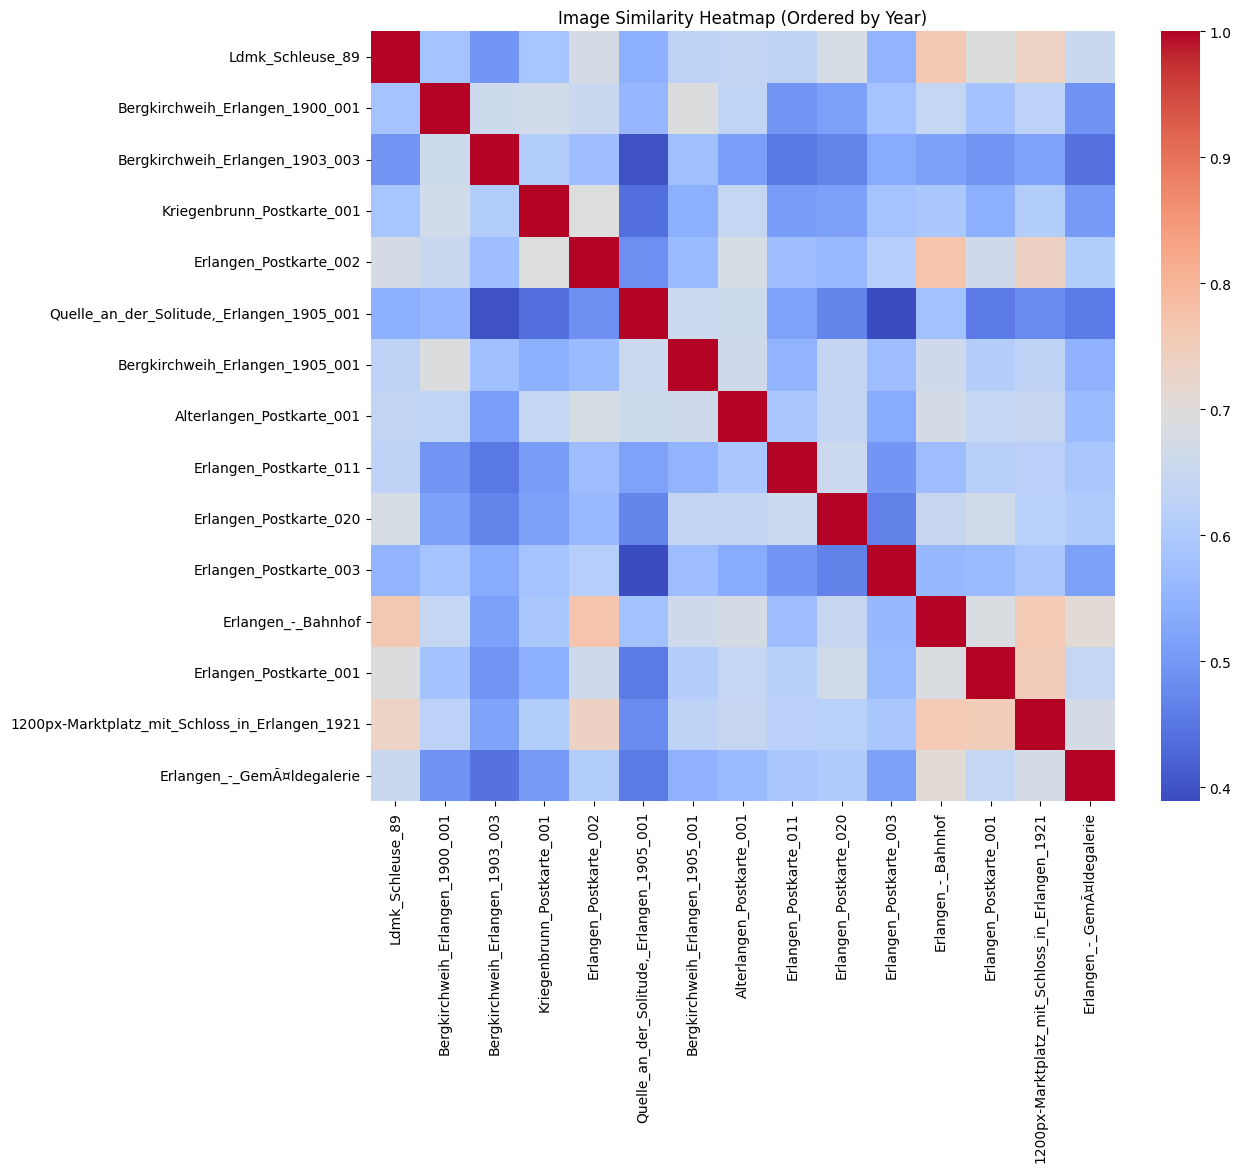

In [11]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# --- Step 1: Load JSON ---
with open("embeddings.json", "r") as f:
    data = json.load(f)

embeddings_dict = data["image"]

# --- Step 2: Load CSV with Year info ---
bh_df = pd.read_csv("BH.csv")  # Make sure this CSV has columns: Filename, Year

# Strip '.jpg' from JSON keys to match CSV
json_filenames = [f.replace('.jpg', '') for f in embeddings_dict.keys()]
embeddings = np.array(list(embeddings_dict.values()))

# --- Step 3: Merge Year info ---
year_df = pd.DataFrame({"Filename": json_filenames})
merged_df = year_df.merge(bh_df[['Filename', 'Year']], on='Filename', how='left')

# Sort filenames by ascending Year
sorted_filenames = merged_df.sort_values('Year')['Filename'].tolist()

# --- Step 4: Compute cosine similarity ---
similarity_matrix = cosine_similarity(embeddings)

# Convert to DataFrame and reorder according to Year
sim_df = pd.DataFrame(similarity_matrix, index=json_filenames, columns=json_filenames)
sim_df = sim_df.loc[sorted_filenames, sorted_filenames]

# --- Step 5: Plot heatmap ---
plt.figure(figsize=(12,10))
sns.heatmap(sim_df, cmap="coolwarm", xticklabels=True, yticklabels=True)
plt.title("Image Similarity Heatmap (Ordered by Year)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()
